**Description** : Modélisation des relations entre employés et entreprises.

**Objectifs** : Construction d'un graphe biparti où les nœuds sont soit des employés, soit des entreprises.

**Analyse** : Calcul des statistiques fondamentales du réseau (nombre de nœuds, d'arêtes et distribution des degrés).

**Importation les bibliothéques nécessaires**

In [1]:
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import random
from networkx.algorithms import bipartite

**Étape 1 : Chargement et Création du Graphe Complet**

In [2]:
# 1. Chargement des données
df = pd.read_csv("../data/linkedin_cleaned_data.csv")

Ici j'ai chargé nos données nettoyés pas la dataset initiale

In [3]:
# 2. On garde les colonnes nécessaires MAIS on ne supprime PAS les lignes (pas de dropna)
df = df[['id', 'name', 'current_company_name']]

In [4]:
# 3. Initialisation du graphe biparti
B = nx.Graph()

In [5]:
# 4. Définition des nœuds Employés (On utilise l'ID pour avoir exactement 1000 nœuds uniques)
employes_ids = df['id'].unique().tolist()

In [6]:
# Définition des nœuds Entreprises (On exclut juste les valeurs vides pour ne pas créer un nœud "NaN")
entreprises = df['current_company_name'].dropna().unique().tolist()

In [7]:
# 5. Ajout des nœuds
# Pour les employés, on ajoute l'ID comme nœud, et le 'name' comme attribut caché
for _, row in df.iterrows():
    B.add_node(row['id'], bipartite=0, name=row['name'])

In [8]:
# Pour les entreprises, le nom de l'entreprise suffit
B.add_nodes_from(entreprises, bipartite=1)

In [9]:
# 6. Ajout des arêtes (liens) UNIQUEMENT pour ceux qui ont une entreprise
# On filtre temporairement juste pour créer les liens
df_avec_entreprise = df.dropna(subset=['current_company_name'])
edges = list(zip(df_avec_entreprise['id'], df_avec_entreprise['current_company_name']))
B.add_edges_from(edges)
print(f"✅ Graphe global créé : {len(employes_ids)} employés (ID uniques) et {len(entreprises)} entreprises.")

✅ Graphe global créé : 1000 employés (ID uniques) et 803 entreprises.


**Étape 2 : Génération de la Matrice d'Adjacence (Bi-adjacence)**

In [10]:
# Génération de la matrice de bi-adjacence
# Lignes = Employés / Colonnes = Entreprises
matrice_bi = bipartite.biadjacency_matrix(B, row_order=employes_ids, column_order=entreprises)

In [11]:
print(f"Format de la matrice : {matrice_bi.shape}")
print(f"C'est une matrice avec {matrice_bi.shape[0]} lignes (employés) et {matrice_bi.shape[1]} colonnes (entreprises).")

Format de la matrice : (1000, 803)
C'est une matrice avec 1000 lignes (employés) et 803 colonnes (entreprises).


In [12]:
# Affichage d'un petit morceau de la matrice (les 5 premiers employés et entreprises) pour visualiser
print("\nAperçu de la matrice (5x5) :")
print(matrice_bi[:5, :5].toarray())


Aperçu de la matrice (5x5) :
[[0 0 0 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]]


In [13]:
# 2. Conversion de la matrice en DataFrame Pandas pour la lisibilité
df_matrice = pd.DataFrame(
    matrice_bi.toarray(), 
    index=employes_ids, 
    columns=entreprises
)

In [14]:
# 3. Sauvegarde en fichier CSV dans le dossier "resultats"
chemin_matrice = "../resultats/matrice_bi_adjacence.csv"
df_matrice.to_csv(chemin_matrice, encoding='utf-8')

print(f"✅ La matrice d'adjacence a été sauvegardée avec succès dans : {chemin_matrice}")

✅ La matrice d'adjacence a été sauvegardée avec succès dans : ../resultats/matrice_bi_adjacence.csv


**Étape 3 : Affichage de la  graphe**

**Visualisation du graphe**

Juste au niveau de visualisation je vais afficher toutes les noeuds puisque mon graphe est énorme 

In [15]:
# 1. Détection des boucles (relations récursives)
boucles = list(nx.selfloop_edges(B))

print(f"🧹 Nombre de boucles détectées (et supprimées) : {len(boucles)}")

# 2. Suppression de ces boucles du graphe global
B.remove_edges_from(boucles)

🧹 Nombre de boucles détectées (et supprimées) : 1


Ici j'ai créé ce code pour éviter les problémes des boucles car il y a dans certain cas l'ID de l'employé est similaire de le nom de company .

In [16]:
# 1. Sélection ciblée : On cherche le Top 10 des entreprises avec le plus d'employés
# On récupère toutes les entreprises (bipartite == 1) et leur nombre de liens (degré)
degres_entreprises = [(noeud, degre) for noeud, degre in B.degree() if B.nodes[noeud]['bipartite'] == 1]

In [17]:
# On trie du plus grand au plus petit et on garde les 10 premières
degres_entreprises.sort(key=lambda x: x[1], reverse=True)
top_10_entreprises = [noeud for noeud, degre in degres_entreprises[:10]]

In [18]:
# 2. On récupère uniquement les employés liés à ce Top 10
employes_du_top = []
for entreprise in top_10_entreprises:
    # B.neighbors trouve tous les employés connectés à cette entreprise
    employes_du_top.extend(list(B.neighbors(entreprise)))

In [19]:
# On enlève les éventuels doublons (au cas où, bien que rare dans ce contexte)
employes_du_top = list(set(employes_du_top))

In [20]:
# 3. Création du sous-graphe temporaire juste pour l'affichage
noeuds_a_garder = top_10_entreprises + employes_du_top
sous_graphe_lisible = B.subgraph(noeuds_a_garder).copy()

✅ Image du graphe sauvegardée avec succès dans : ../resultats/graphe_top10_entreprises.png


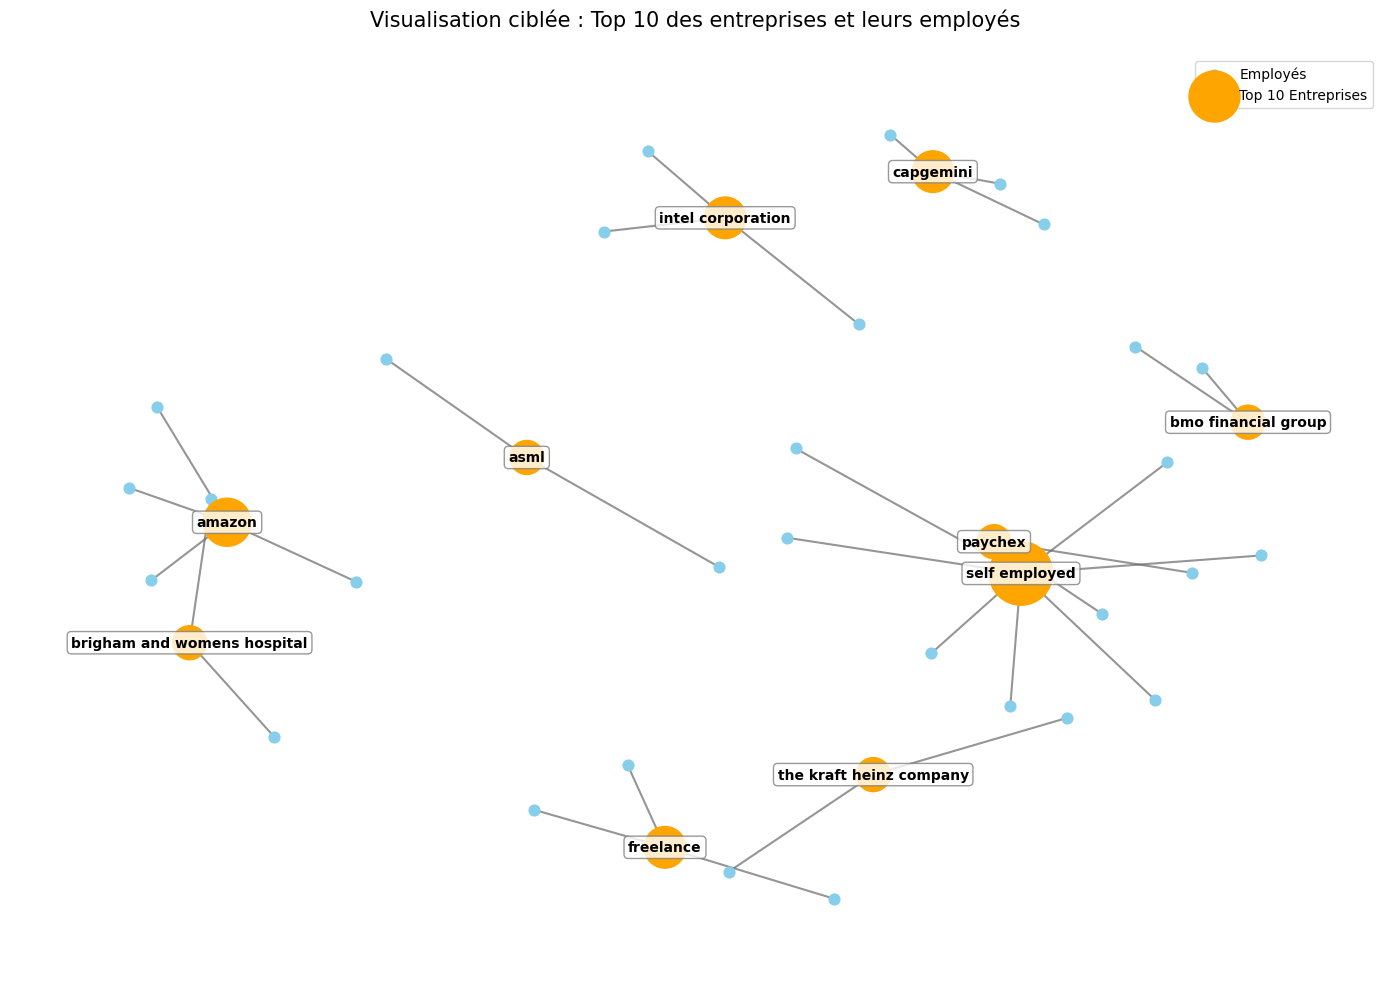

In [21]:
# --- VISUALISATION ---
plt.figure(figsize=(14, 10))

# Disposition optimisée
pos = nx.spring_layout(sous_graphe_lisible, k=0.5, iterations=50, seed=42)

# Dessin des employés (bleu)
nx.draw_networkx_nodes(sous_graphe_lisible, pos, nodelist=employes_du_top, 
                       node_color='skyblue', node_size=60, label='Employés')

# Dessin des entreprises (orange, taille dynamique)
tailles_entreprises = [sous_graphe_lisible.degree(node) * 300 for node in top_10_entreprises]
nx.draw_networkx_nodes(sous_graphe_lisible, pos, nodelist=top_10_entreprises, 
                       node_color='orange', node_size=tailles_entreprises, label='Top 10 Entreprises')

# Dessin des arêtes (bien visibles)
nx.draw_networkx_edges(sous_graphe_lisible, pos, alpha=0.7, edge_color='dimgray', width=1.5)

# Noms des entreprises (avec fond blanc pour la lisibilité)
labels_entreprises = {node: node for node in top_10_entreprises}
nx.draw_networkx_labels(sous_graphe_lisible, pos, labels_entreprises, font_size=10, font_weight='bold', 
                        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3', alpha=0.8))

# Configuration de la légende et du titre
plt.title("Visualisation ciblée : Top 10 des entreprises et leurs employés", fontsize=15, pad=20)
plt.legend(scatterpoints=1, loc='upper right')
plt.axis('off')
plt.tight_layout()
# --- SAUVEGARDE DE L'IMAGE ---
chemin_image = "../resultats/graphe_top10_entreprises.png"
plt.savefig(chemin_image, dpi=300, bbox_inches='tight')
print(f"✅ Image du graphe sauvegardée avec succès dans : {chemin_image}")
plt.show()

**Etape4:Analyser le graphe biparti**

Dans cette étape , j'ai analysé mon graphe biparti en utilisant des différents mesures locales et globale. Pour les mesures locales , j'ai concentré uniquement sur les entreprises puisque dans mon propore cas chaque employé posséde uniquement une entrerprise

In [22]:
# 1. Calcul de la Densité du graphe biparti
# On utilise la fonction spécifique de NetworkX pour les graphes bipartis
densite = bipartite.density(B, employes_ids)

## 🔷 Densité d’un graphe biparti

La **densité** d’un graphe mesure à quel point les nœuds sont connectés entre eux.
Elle représente le rapport entre le nombre de liens existants et le nombre maximum de liens possibles.

---

### 🔹 Cas d’un graphe biparti

Dans un graphe biparti, les nœuds sont divisés en deux ensembles distincts :

* (U) : ensemble des employés
* (V) : ensemble des entreprises

Les liens existent uniquement entre (U) et (V) (et jamais à l’intérieur d’un même ensemble).

---

### 🔹 Formule de la densité

Density = \frac{|E|}{|U| \times |V|}

où :

* (|E|) : nombre de liens existants
* (|U|) : nombre d’employés
* (|V|) : nombre d’entreprises

---

### 🔹 Interprétation

* **Densité proche de 1** :

  * le graphe est très dense
  * presque tous les employés sont connectés à toutes les entreprises

* **Densité proche de 0** :

  * le graphe est peu connecté (sparse)
  * chaque employé est lié à peu d’entreprises

---

### 🔹 Dans notre cas

Dans un réseau Employé–Entreprise :

* chaque employé travaille généralement dans une seule entreprise
* donc le nombre de liens est faible par rapport au maximum possible

👉 Cela implique que la densité est généralement **très faible**, ce qui est **normal** pour ce type de graphe.





In [23]:
# 2. Calcul des Degrés (nombre d'employés par entreprise)
degres = dict(B.degree(entreprises))

## 🔷 Degré dans un graphe biparti (Employé – Entreprise)

Le **degré (Degree)** d’un nœud correspond au **nombre de connexions (liens)** qu’il possède avec d’autres nœuds.

---

### 🔹 Cas d’un graphe biparti

Dans notre graphe biparti, les nœuds sont divisés en deux ensembles :

* (U) : ensemble des employés
* (V) : ensemble des entreprises

Les liens existent uniquement entre employés et entreprises.

---


---

### 🔹 Interprétation dans notre cas

#### ✔️ Pour un employé :

* Le degré correspond au **nombre d’entreprises** dans lesquelles il travaille
* Dans notre dataset :

  * généralement **deg(employé) = 1**

---

#### ✔️ Pour une entreprise :

* Le degré correspond au **nombre d’employés** qui y travaillent

👉 C’est une mesure très importante car elle permet d’évaluer :

* la taille d’une entreprise
* son attractivité
* son importance dans le réseau







### 🔹 Distribution des degrés

L’analyse de la distribution des degrés des entreprises permet de :

* identifier les entreprises ayant le plus d’employés
* observer si quelques entreprises dominent le réseau
* détecter une éventuelle concentration (ex : grandes vs petites entreprises)

---



In [24]:
# 3. Calcul de la Centralité de Degré (Degree Centrality)
# Calcule la proportion de connexions d'une entreprise par rapport au total d'employés
centralites = bipartite.degree_centrality(B, employes_ids)

## 🔷 Centralité de degré dans un graphe biparti

La **centralité de degré (Degree Centrality)** mesure l’importance d’un nœud en fonction du nombre de connexions qu’il possède, tout en normalisant cette valeur pour permettre la comparaison entre nœuds.

---

### 🔹 Définition générale

C_D(v) = \frac{deg(v)}{N - 1}

où :

* (deg(v)) : degré du nœud
* (N) : nombre total de nœuds dans le graphe

---

### 🔹 Cas spécifique du graphe biparti

Dans un graphe biparti, les connexions sont limitées entre deux ensembles :

* (U) : employés
* (V) : entreprises

Ainsi, la centralité est calculée en tenant compte uniquement des connexions possibles vers l’autre ensemble.

---

### 🔹 Calcul avec NetworkX

Dans notre implémentation, la centralité est calculée avec :

```python
centralites = bipartite.degree_centrality(B, employes_ids)
```

👉 Cette fonction calcule la centralité de degré pour les nœuds spécifiés (ici les employés), en les normalisant par rapport au nombre de nœuds du groupe opposé (les entreprises).

---

### 🔹 Interprétation dans notre cas

#### ✔️ Pour un employé :

* La centralité indique à combien d’entreprises il est connecté (normalisé)
* Dans notre dataset :

  * généralement très faible (souvent proche de 0), car chaque employé travaille dans une seule entreprise

---

#### ✔️ Pour une entreprise :

* La centralité reflète le nombre d’employés connectés
* Une centralité élevée indique :

  * une entreprise importante
  * fortement connectée dans le réseau







In [25]:
# 4. Création d'un DataFrame pour organiser les résultats
df_mesures = pd.DataFrame({
    'Entreprise': entreprises,
    'Degré (Nb employés)': [degres[e] for e in entreprises],
    'Centralité de Degré': [centralites[e] for e in entreprises]
})

In [26]:
# On trie du plus grand degré au plus petit pour avoir les plus importantes en haut
df_mesures = df_mesures.sort_values(by='Degré (Nb employés)', ascending=False).reset_index(drop=True)

In [27]:
# --- AFFICHAGE DANS LE NOTEBOOK ---
print("=== ANALYSE GLOBALE ===")
print(f"Densité du graphe biparti : {densite:.5f}")
print("(Proportion d'arêtes existantes par rapport au maximum d'arêtes possibles entre employés et entreprises)\n")

print("=== TOP 10 DES ENTREPRISES LES PLUS IMPORTANTES ===")
# On affiche les 10 premières lignes sans l'index numérique pour faire plus propre
print(df_mesures.head(10).to_string(index=False))

=== ANALYSE GLOBALE ===
Densité du graphe biparti : 0.00103
(Proportion d'arêtes existantes par rapport au maximum d'arêtes possibles entre employés et entreprises)

=== TOP 10 DES ENTREPRISES LES PLUS IMPORTANTES ===
                 Entreprise  Degré (Nb employés)  Centralité de Degré
              self employed                    7                0.007
                     amazon                    4                0.004
                  freelance                    3                0.003
          intel corporation                    3                0.003
                  capgemini                    3                0.003
        bmo financial group                    2                0.002
                       asml                    2                0.002
brigham and womens hospital                    2                0.002
    the kraft heinz company                    2                0.002
                        sap                    2                0.002


In [28]:
# --- SAUVEGARDE DANS LE DOSSIER 'RESULTATS' ---
# A. Sauvegarde du tableau complet en CSV (pratique pour Excel ou de futures analyses)
chemin_csv = "../resultats/mesures_entreprises.csv"
df_mesures.to_csv(chemin_csv, index=False, encoding='utf-8')

In [29]:
# B. Sauvegarde d'un petit rapport texte 
chemin_txt = "../resultats/rapport_analyse_reseau.txt"
with open(chemin_txt, "w", encoding="utf-8") as f:
    f.write("=== MESURES DU GRAPHE BIPARTI ===\n\n")
    f.write(f"Densité globale du graphe : {densite:.5f}\n\n")
    f.write("=== TOP 20 DES ENTREPRISES (Degré & Centralité) ===\n")
    f.write(df_mesures.head(20).to_string(index=False))

print(f"\n✅ Vos résultats d'analyse ont été sauvegardés avec succès !")
print(f"📁 Fichier complet (CSV) : {chemin_csv}")
print(f"📄 Rapport résumé (TXT) : {chemin_txt}")


✅ Vos résultats d'analyse ont été sauvegardés avec succès !
📁 Fichier complet (CSV) : ../resultats/mesures_entreprises.csv
📄 Rapport résumé (TXT) : ../resultats/rapport_analyse_reseau.txt
